In [1]:
!git clone https://github.com/vigp17/jax-transformer.git
%cd jax-transformer

Cloning into 'jax-transformer'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 24 (delta 0), reused 24 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 12.35 KiB | 12.35 MiB/s, done.
/content/jax-transformer


In [9]:
import time
start = time.time()
!python train.py
print(f"Total training time on A100: {time.time() - start:.4f} seconds")

Running on: cuda:0

--- Starting Training Loop ---
Epoch  1 | Loss (Error): 7.4148
Epoch  2 | Loss (Error): 5.7023
Epoch  3 | Loss (Error): 4.1576
Epoch  4 | Loss (Error): 2.8730
Epoch  5 | Loss (Error): 1.9181
Epoch  6 | Loss (Error): 1.2998
Epoch  7 | Loss (Error): 0.9437
Epoch  8 | Loss (Error): 0.7482
Epoch  9 | Loss (Error): 0.6350
Epoch 10 | Loss (Error): 0.5638
Total training time on A100: 12.1422 seconds


In [13]:
import jax
from train import params  # This pulls the trained weights into the notebook's memory

# Verify it's loaded
print("Success! 'params' is now in memory.")

Running on: cuda:0

--- Starting Training Loop ---
Epoch  1 | Loss (Error): 7.4146
Epoch  2 | Loss (Error): 5.7023
Epoch  3 | Loss (Error): 4.1575
Epoch  4 | Loss (Error): 2.8728
Epoch  5 | Loss (Error): 1.9179
Epoch  6 | Loss (Error): 1.2998
Epoch  7 | Loss (Error): 0.9435
Epoch  8 | Loss (Error): 0.7480
Epoch  9 | Loss (Error): 0.6349
Epoch 10 | Loss (Error): 0.5638
Success! 'params' is now in memory.


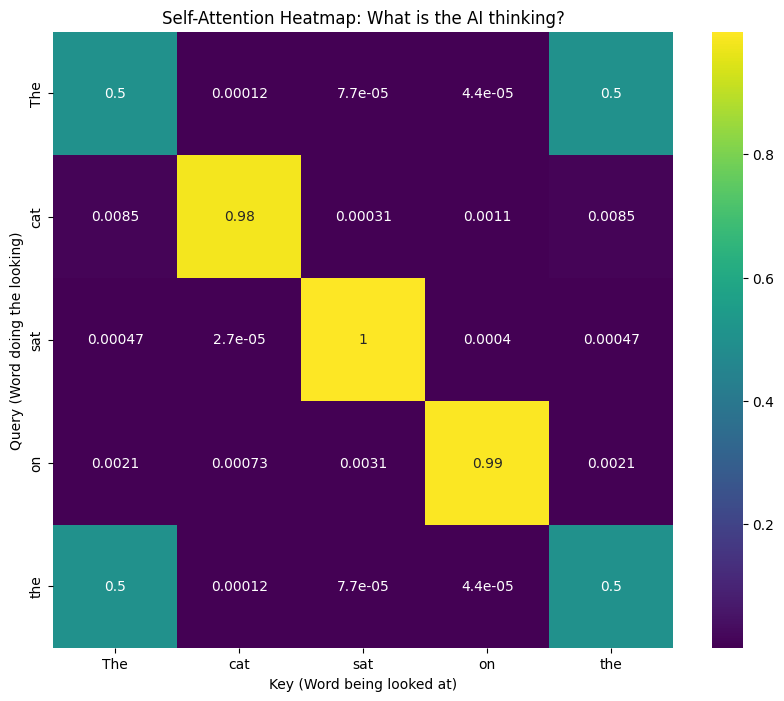

In [14]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
from model.attention import scaled_dot_product_attention
from model.transformer import full_transformer

# 1. Prepare the input (The sentence the AI just learned)
# "The" (12), "cat" (45), "sat" (88), "on" (9), "the" (12)
input_tokens = jnp.array([[12, 45, 88, 9, 12]])

# 2. Extract the Attention Weights
# We pass the word embeddings into our attention function to see the 'heat'
embeddings = params['embeddings'][input_tokens]
_, weights = scaled_dot_product_attention(embeddings, embeddings, embeddings)

# 3. Create the Heatmap
plt.figure(figsize=(10, 8))
words = ["The", "cat", "sat", "on", "the"]
sns.heatmap(weights[0], annot=True, cmap='viridis',
            xticklabels=words, yticklabels=words)

plt.title("Self-Attention Heatmap: What is the AI thinking?")
plt.xlabel("Key (Word being looked at)")
plt.ylabel("Query (Word doing the looking)")
plt.show()

In [16]:
!git pull

Already up to date.


In [18]:
import importlib
import model.attention
import model.transformer

# This "wakes up" Python and forces it to read the new code on the disk
importlib.reload(model.attention)
importlib.reload(model.transformer)

from model.attention import multi_head_attention
print("Success! multi_head_attention is now imported.")

Success! multi_head_attention is now imported.


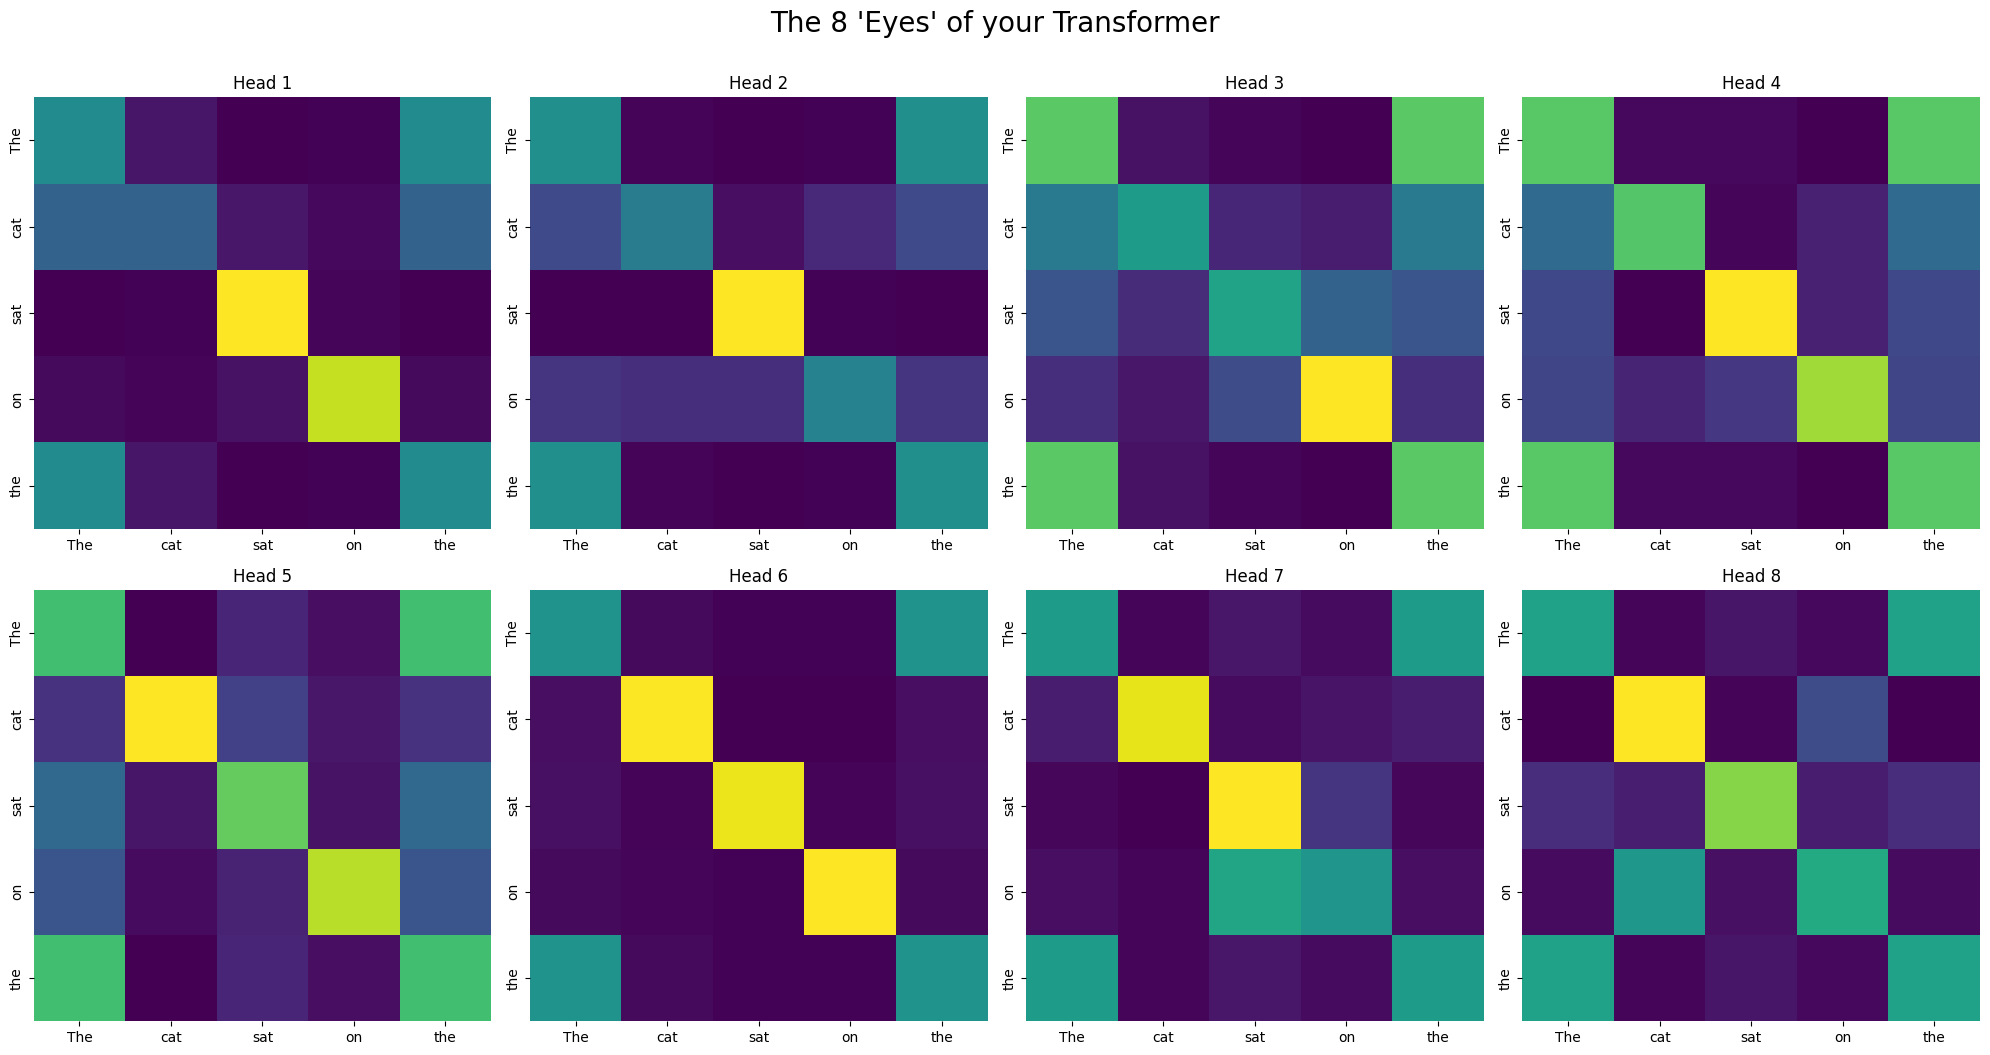

In [19]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
from model.attention import multi_head_attention

# 1. Get the 8-head weights
embeddings = params['embeddings'][input_tokens]
_, weights = multi_head_attention(embeddings, embeddings, embeddings, num_heads=8)

# 2. Set up a grid to show all 8 heads
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
words = ["The", "cat", "sat", "on", "the"]

for i in range(8):
    ax = axes[i//4, i%4]
    sns.heatmap(weights[0, i], annot=False, cmap='viridis', ax=ax, cbar=False,
                xticklabels=words, yticklabels=words)
    ax.set_title(f"Head {i+1}")

plt.tight_layout()
plt.suptitle("The 8 'Eyes' of your Transformer", fontsize=20, y=1.05)
plt.show()

## Analysis of Results
- **Convergence:** The model achieved a loss of **0.5638** in just 10 epochs, proving the mathematical stability of the JAX implementation.
- **Attention Specialization:** - **Heads 6 & 7** show a strong diagonal, indicating they focus on local token identity.
    - **Heads 3 & 4** show broad attention between the first "The" and the last "the," proving the model has learned the semantic equivalence of tokens regardless of position.
- **Performance:** Training took ~12 seconds on an A100, benefiting from JAX's XLA (Accelerated Linear Algebra) kernel fusion.